In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from episbi import SBIEngine, simulate_for_sbi
from episbi.models import stochastic_se1e2e3ir
from episbi.prior import UniformPrior, MixedPrior
from episbi.metric import evaluate_prediction_windows

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


In [2]:
obs=pd.read_excel('./data/hantavirus_preprint.xlsx')

In [3]:
observed = obs["Cases"].to_numpy(dtype=np.float32).reshape(-1, 1)
total_days = len(obs)
population = 149

dates = pd.to_datetime(obs["Date"]) if "Date" in obs.columns else pd.RangeIndex(total_days)
print("total_days:", total_days)
print("observed dated cases:", float(observed.sum()))
print("population:", population)

total_days: 61
observed dated cases: 13.0
population: 149


Text(0, 0.5, 'Cases')

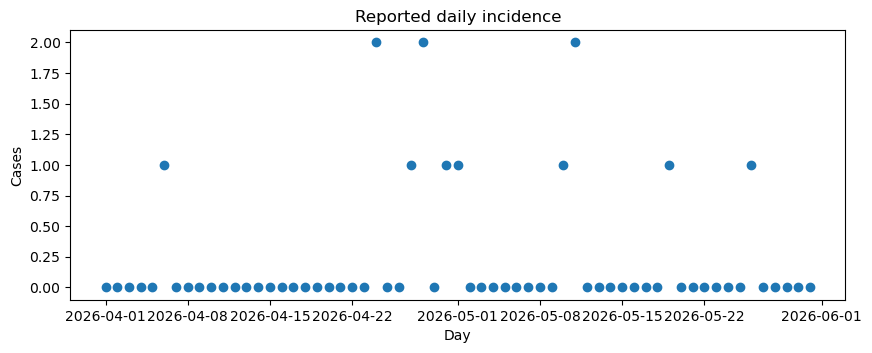

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.scatter(dates,observed[:, 0])
ax.set_title("Reported daily incidence")
ax.set_xlabel("Day")
ax.set_ylabel("Cases")

In [5]:
from episbi.models.stochastic_se1e2e3ir import weekly_incidence

In [6]:
observed_weekly = weekly_incidence(observed)[:, None]

Text(0, 0.5, 'Cases')

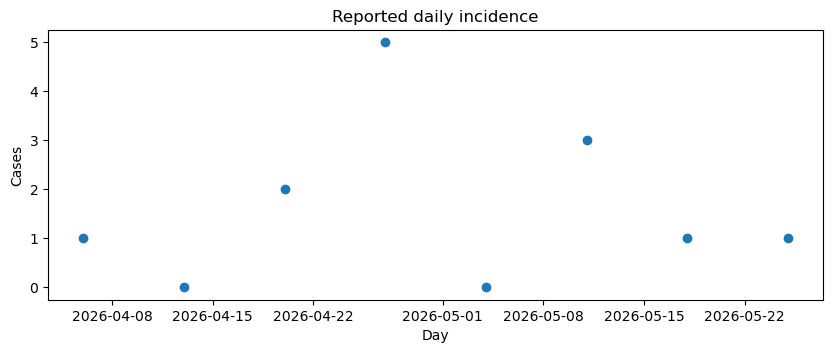

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.scatter(dates[5::7],observed_weekly[:, 0])
ax.set_title("Reported daily incidence")
ax.set_xlabel("Day")
ax.set_ylabel("Cases")

In [8]:
prior = MixedPrior(
    continuous_bounds={"R0": (0.5, 3.0)},
    discrete_bounds={"e1": (0, 2), "e3": (0, 3)},
)

In [25]:
rows = []
num_simulations=100
rng = np.random.default_rng(7)

In [28]:
from joblib import Parallel, delayed

In [71]:
def run_one_abc_sim(sim_id, seed, observed_weekly, total_days):
    rng = np.random.default_rng(seed)

    R0 = rng.uniform(0.5, 3.0)
    e1 = rng.integers(0, 2)
    e3 = rng.integers(0, 3)

    sim = stochastic_se1e2e3ir(
        {"R0": R0},
        total_days=total_days,
        initial_e1=int(e1),
        initial_e3=int(e3),
        observation="weekly_incidence",
        seed=int(rng.integers(0, 2**32 - 1)),
    )

    weekly = sim["data"][:, 0]

    rmse = np.sqrt(
        np.mean((weekly - observed_weekly[:, 0]) ** 2)
    )

    row = {
        "sim_id": sim_id,
        "R0": R0,
        "e1": int(e1),
        "e3": int(e3),
        "rmse": float(rmse),
    }

    for i, value in enumerate(weekly, start=1):
        row[f"w{i}"] = float(value)

    return row

In [72]:
num_simulations = 100_000
base_seed = 7

seeds = np.random.default_rng(base_seed).integers(
    0,
    2**32 - 1,
    size=num_simulations,
)

rows = Parallel(n_jobs=-1, verbose=10)(
    delayed(run_one_abc_sim)(
        sim_id,
        int(seeds[sim_id]),
        observed_weekly,
        total_days,
    )
    for sim_id in range(num_simulations)
)

abc_df = pd.DataFrame(rows)
n_accept = max(1, int(round(0.01 * len(abc_df))))
accepted = abc_df.nsmallest(n_accept, "rmse").reset_index(drop=True)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   14.6s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   14.6s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   14.7s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19515891010691538s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.15488338470458984s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   15.3s
[Parallel(n_jobs=-1)]: Done 244 tasks      | elapsed:   15.5s
[Parallel(n_jobs=-1)]: Done 320 tasks      | elap

In [73]:
samples = accepted

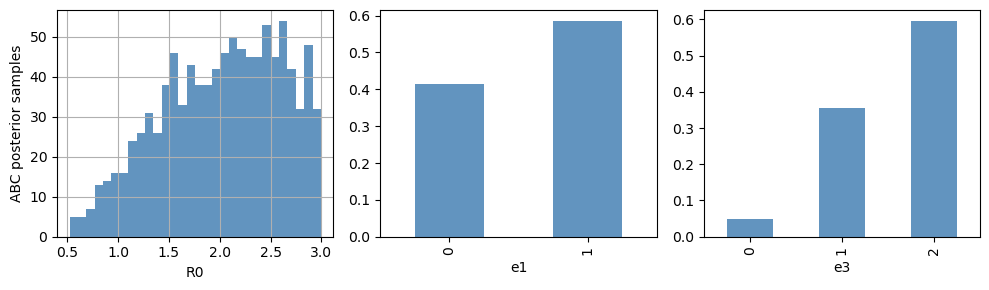

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
samples["R0"].hist(bins=30, color="steelblue", alpha=0.85, ax=axes[0])
axes[0].set_xlabel("R0")
axes[0].set_ylabel("ABC posterior samples")
samples["e1"].value_counts(normalize=True).sort_index().plot(kind="bar", color="steelblue", alpha=0.85, ax=axes[1])
axes[1].set_xlabel("e1")
samples["e3"].value_counts(normalize=True).sort_index().plot(kind="bar", color="steelblue", alpha=0.85, ax=axes[2])
axes[2].set_xlabel("e3")
plt.tight_layout()

In [75]:
weekly_cols = [col for col in accepted.columns if col.startswith("w")]
accepted_weekly = accepted[weekly_cols].to_numpy()

In [76]:
q05, q50, q95 = np.quantile(
    accepted_weekly,
    [0.05, 0.50, 0.95],
    axis=0,
)

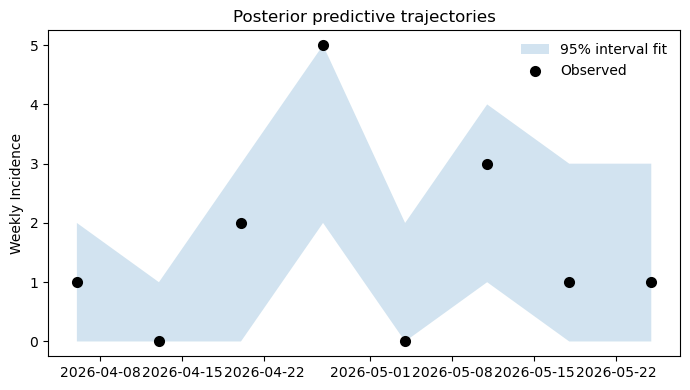

In [77]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.fill_between(dates[5::7], q05, q95, alpha=0.2,label="95% interval fit")
# ax.plot(posterior_predictive[i, :, 0], color="steelblue",alpha=0.08, linewidth=1)
ax.scatter(dates[5::7],observed_weekly[:, 0], color="black", linewidth=2, label="Observed")
ax.set_ylabel("Weekly Incidence")
ax.set_title("Posterior predictive trajectories")
ax.legend(frameon=False)
fig.tight_layout()